# Dataset Hugging Face - Vessel Detection Labeled Patches

Ce notebook analyse la vraie donnée indiquée dans le README : `DefendIntelligence/vessel-detection-labeled-patches`.

Objectif : comprendre rapidement la structure du dataset sans télécharger 1 Go inutilement.

Stratégie retenue :

- télécharger les métadonnées complètes ;
- télécharger les splits et les labels YOLO, qui sont légers ;
- télécharger seulement un petit échantillon d'images pour visualiser les annotations ;
- vérifier si cette donnée correspond au besoin du sujet 5.

Conclusion à garder en tête : ce dataset est très utile pour apprendre à détecter des bateaux, mais il ne suffit pas à lui seul pour classifier des navires militaires.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

DATA_DIR = Path('../data/vessel-detection-labeled-patches')
if not DATA_DIR.exists():
    DATA_DIR = Path('data/vessel-detection-labeled-patches')

SUMMARY_PATH = DATA_DIR / 'dataset_summary.json'
METADATA_PATH = DATA_DIR / 'metadata.csv'
ANNOTATIONS_PATH = DATA_DIR / 'annotations.csv'
SAMPLE_MANIFEST_PATH = DATA_DIR / 'sample_manifest.csv'

with open(SUMMARY_PATH, 'r', encoding='utf-8') as f:
    summary = json.load(f)

metadata = pd.read_csv(METADATA_PATH)
annotations = pd.read_csv(ANNOTATIONS_PATH)
sample_manifest = pd.read_csv(SAMPLE_MANIFEST_PATH) if SAMPLE_MANIFEST_PATH.exists() else metadata.head(0)

summary

{'dataset_repo_id': 'DefendIntelligence/vessel-detection-labeled-patches',
 'generated_at': '2026-05-01T11:49:03+00:00',
 'source_database': 'data/app_index.sqlite3',
 'selection': {'review_status': ['reviewed', 'reviewed_local'],
  'synthetic': False,
  'source_table': 'captures JOIN review_patch_status ON review_id=capture_id'},
 'patch_count': 1920,
 'object_annotation_count': 1347,
 'label_counts': {'hard_negative': 844, 'boat': 1076},
 'dataset_counts': {'sentinel-1-vv': 1,
  'sentinel-2-rgb': 1917,
  'sentinel-2-swir': 2},
 'review_status_counts': {'reviewed': 301, 'reviewed_local': 1619},
 'split_counts': {'train': 1516, 'test': 219, 'validation': 185},
 'vessel_type_counts': {'porte-conteneur': 531, 'inconnu': 816},
 'missing_images': [],
 'invalid_annotations': [],
 'invalid_annotation_count': 0}

## 1. Ce qui a été récupéré

Le dataset complet fait environ 1 Go si on télécharge toutes les images. Pour aller vite, on a récupéré :

- les fichiers de description (`README.md`, `dataset_summary.json`) ;
- les métadonnées (`metadata.csv`, `metadata.jsonl`) ;
- les annotations (`annotations.csv`, `annotations.jsonl`) ;
- les splits train / validation / test ;
- les labels YOLO ;
- un petit échantillon de patches image.

Les images complètes restent volontairement non téléchargées.

In [2]:
print(f"Patches déclarés : {summary['patch_count']}")
print(f"Annotations objet : {summary['object_annotation_count']}")
print(f"Lignes metadata.csv : {len(metadata)}")
print(f"Lignes annotations.csv : {len(annotations)}")
print(f"Images échantillon téléchargées : {len(sample_manifest)}")

print('\nRépartition sample_type :')
display(metadata['sample_type'].value_counts().to_frame('nombre'))

print('\nRépartition datasets/capteurs :')
display(metadata['dataset'].value_counts().to_frame('nombre'))

print('\nRépartition splits :')
display(metadata['split'].value_counts().to_frame('nombre'))

Patches déclarés : 1920
Annotations objet : 1347
Lignes metadata.csv : 1920
Lignes annotations.csv : 1347
Images échantillon téléchargées : 24

Répartition sample_type :


,nombre
sample_type,
boat,1076
hard_negative,844



Répartition datasets/capteurs :


,nombre
dataset,
sentinel-2-rgb,1917
sentinel-2-swir,2
sentinel-1-vv,1



Répartition splits :


,nombre
split,
train,1516
test,219
validation,185


## 2. Structure de `metadata.csv`

`metadata.csv` contient une ligne par patch image. C'est la table la plus utile pour comprendre le dataset au niveau image.

Colonnes importantes :

- `file_name` : chemin de l'image dans le dataset ;
- `label_file` : chemin du label YOLO associé ;
- `split` : train, validation ou test ;
- `sample_type` : `boat` ou `hard_negative` ;
- `dataset` : source/capteur, surtout Sentinel-2 RGB ;
- `image_width`, `image_height` : dimensions du patch ;
- `object_count`, `annotation_count` : nombre de bateaux annotés ;
- `patch_latitude`, `patch_longitude` : centre géographique du patch ;
- `patch_west`, `patch_south`, `patch_east`, `patch_north` : bbox géographique du patch ;
- `objects_json` : objets annotés sous forme JSON.

In [3]:
print('Colonnes disponibles dans metadata.csv :')
for col in metadata.columns:
    print('-', col)

metadata.head(3)

Colonnes disponibles dans metadata.csv :
- file_name
- label_file
- capture_id
- split
- sample_type
- label
- vessel_type
- review_status
- review_updated_at
- created_at
- dataset
- dataset_label
- imagery_type
- source_key
- composite_mode
- days_back
- end_date
- cell_id
- image_width
- image_height
- image_mode
- object_count
- annotation_count
- detection_count
- patch_latitude
- patch_longitude
- patch_west
- patch_south
- patch_east
- patch_north
- patch_area_deg2
- scene_latitude
- scene_longitude
- scene_west
- scene_south
- scene_east
- scene_north
- inference_run_id
- inference_detection_id
- inference_grid_cell
- inference_confidence
- inference_day_key
- inference_day_label
- review_source_id
- notes
- objects_json


,file_name,label_file,capture_id,split,sample_type,label,vessel_type,review_status,review_updated_at,created_at,...,scene_north,inference_run_id,inference_detection_id,inference_grid_cell,inference_confidence,inference_day_key,inference_day_label,review_source_id,notes,objects_json
0,images/sentinel-1-vv/hard_negative/patch-3ee21...,labels/sentinel-1-vv/hard_negative/patch-3ee21...,patch-3ee21e7988199f2d,train,hard_negative,background,NaN,reviewed,2026-04-29T11:03:53.546052+00:00,2026-03-22T01:31:00.010991Z,...,30.900000,NaN,NaN,r77c27,NaN,NaN,NaN,NaN,NaN,[]
1,images/sentinel-2-rgb/boat/patch-233e2d77f8a0b...,labels/sentinel-2-rgb/boat/patch-233e2d77f8a0b...,patch-233e2d77f8a0b4d3,train,boat,boat,porte-conteneur,reviewed,2026-04-29T11:03:53.546052+00:00,2026-03-22T11:27:25.686293Z,...,31.757071,NaN,NaN,r6c5,NaN,NaN,NaN,NaN,NaN,"[{""annotation_id"":""patch-54eb85f54a847fdc-ann-..."
2,images/sentinel-2-rgb/boat/patch-7f6786c2b42ac...,labels/sentinel-2-rgb/boat/patch-7f6786c2b42ac...,patch-7f6786c2b42ac27a,train,boat,boat,porte-conteneur,reviewed,2026-04-29T11:03:53.546052+00:00,2026-03-22T11:27:25.686293Z,...,31.757071,NaN,NaN,r5c4,NaN,NaN,NaN,NaN,NaN,"[{""annotation_id"":""patch-54eb85f54a847fdc-ann-..."


## 3. Structure de `annotations.csv`

`annotations.csv` contient une ligne par bateau annoté.

C'est la table la plus utile pour la détection d'objet : elle donne les bounding boxes en pixels et au format YOLO normalisé.

In [4]:
print('Colonnes disponibles dans annotations.csv :')
for col in annotations.columns:
    print('-', col)

annotations.head(3)

Colonnes disponibles dans annotations.csv :
- file_name
- capture_id
- annotation_id
- split
- dataset
- sample_type
- label
- vessel_type
- review_status
- patch_latitude
- patch_longitude
- boat_latitude
- boat_longitude
- boat_bbox_west
- boat_bbox_south
- boat_bbox_east
- boat_bbox_north
- x_min
- y_min
- x_max
- y_max
- x_center
- y_center
- width
- height
- x_center_norm
- y_center_norm
- width_norm
- height_norm
- clipped_to_patch


,file_name,capture_id,annotation_id,split,dataset,sample_type,label,vessel_type,review_status,patch_latitude,...,y_max,x_center,y_center,width,height,x_center_norm,y_center_norm,width_norm,height_norm,clipped_to_patch
0,images/sentinel-2-rgb/boat/patch-233e2d77f8a0b...,patch-233e2d77f8a0b4d3,patch-54eb85f54a847fdc-ann-02b160b8,train,sentinel-2-rgb,boat,boat,porte-conteneur,reviewed,31.505954,...,91.7399,22.4532,81.6849,20.7481,20.1099,0.035083,0.127633,0.032419,0.031422,False
1,images/sentinel-2-rgb/boat/patch-7f6786c2b42ac...,patch-7f6786c2b42ac27a,patch-54eb85f54a847fdc-ann-ec5f73b5,train,sentinel-2-rgb,boat,boat,porte-conteneur,reviewed,31.448462,...,245.3060,103.3418,230.1296,30.3647,30.3528,0.161472,0.359578,0.047445,0.047426,False
2,images/sentinel-2-rgb/boat/patch-0a2c751c0eba5...,patch-0a2c751c0eba57ca,patch-0976d9d6e68ac3a5-ann-abebcbb8,test,sentinel-2-rgb,boat,boat,porte-conteneur,reviewed,31.563446,...,34.8138,220.4142,17.4069,59.3352,34.8138,0.344397,0.027198,0.092711,0.054397,True


## 4. Compréhension métier de la donnée

Cette donnée est différente des fichiers d'exemple du sujet 5.

Dans les fichiers d'exemple, on avait des catégories riches : frégate, destroyer, porte-avions, cargo, etc.

Dans ce dataset Hugging Face, la tâche est plus simple :

- classe positive : `boat` ;
- classe négative : `background` / `hard_negative` ;
- type de navire souvent limité à `porte-conteneur` ou `inconnu`.

Donc cette donnée est bonne pour entraîner ou tester une brique de détection de bateaux, mais pas pour distinguer directement civil / militaire.

In [5]:
display(metadata[['sample_type', 'label', 'vessel_type']].value_counts(dropna=False).to_frame('nombre'))

display(annotations['vessel_type'].value_counts(dropna=False).to_frame('nombre_annotations'))

nombre
sample_type   label      vessel_type            
hard_negative background NaN                 844
boat          boat       inconnu             774
                         porte-conteneur     302

,nombre_annotations
vessel_type,
inconnu,816
porte-conteneur,531


## 5. Qualité et format des annotations

Les annotations contiennent :

- coordonnées géographiques du bateau ;
- bbox géographique du bateau ;
- bbox pixel : `x_min`, `y_min`, `x_max`, `y_max` ;
- bbox YOLO : `x_center_norm`, `y_center_norm`, `width_norm`, `height_norm` ;
- indicateur `clipped_to_patch`, utile si le bateau est coupé par le bord du patch.

In [6]:
bbox_stats = annotations[['width', 'height', 'width_norm', 'height_norm']].describe().round(3)
display(bbox_stats)

clipped_rate = annotations['clipped_to_patch'].mean() * 100
print(f"Annotations coupées par le bord du patch : {clipped_rate:.1f}%")

annotations['bbox_area_pct'] = annotations['width_norm'] * annotations['height_norm'] * 100
print(f"Surface moyenne des bbox : {annotations['bbox_area_pct'].mean():.3f}% du patch")
display(annotations.groupby('vessel_type')['bbox_area_pct'].agg(['count', 'mean', 'median']).round(3))

,width,height,width_norm,height_norm
count,1347.000,1347.000,1347.000,1347.000
mean,37.419,34.436,0.058,0.054
std,23.060,24.308,0.036,0.038
min,6.372,6.011,0.010,0.009
25%,22.625,19.776,0.035,0.031
50%,33.378,29.322,0.052,0.046
75%,46.510,42.970,0.073,0.067
max,240.702,461.803,0.376,0.722


Annotations coupées par le bord du patch : 3.7%
Surface moyenne des bbox : 0.432% du patch


,count,mean,median
vessel_type,,,
inconnu,816,0.399,0.289
porte-conteneur,531,0.483,0.160


## 6. Visualisation d'un patch avec ses bounding boxes

La cellule suivante affiche une image téléchargée dans l'échantillon et dessine les bounding boxes issues de `annotations.csv`.

Si l'image n'est pas téléchargée localement, elle est ignorée.

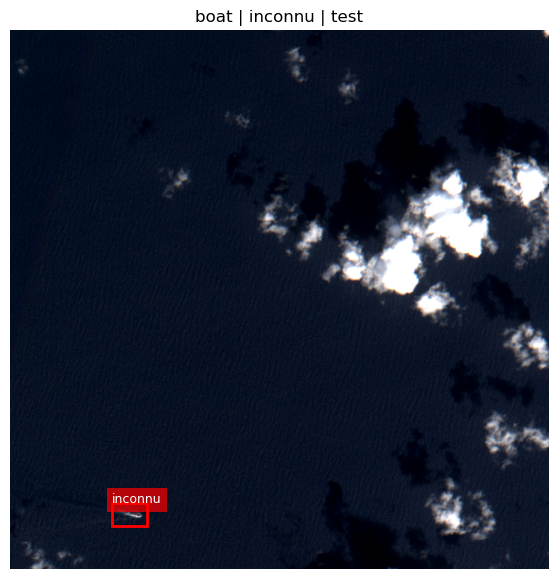

In [7]:
def show_patch(row_index=0):
    if sample_manifest.empty:
        print('Aucun sample_manifest.csv trouvé. Lance scripts/download_hf_vessel_sample.py pour récupérer quelques images.')
        return

    row = sample_manifest.iloc[row_index]
    image_path = DATA_DIR / row['file_name']
    if not image_path.exists():
        print(f"Image absente localement : {image_path}")
        return

    img = plt.imread(image_path)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(img)
    ax.set_title(f"{row['sample_type']} | {row['vessel_type']} | {row['split']}")

    ann = annotations[annotations['file_name'] == row['file_name']]
    for _, obj in ann.iterrows():
        x = obj['x_min']
        y = obj['y_min']
        w = obj['x_max'] - obj['x_min']
        h = obj['y_max'] - obj['y_min']
        ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2))
        ax.text(x, y, obj['vessel_type'], color='white', fontsize=9,
                bbox=dict(facecolor='red', alpha=0.7, edgecolor='none'))

    ax.axis('off')
    plt.show()

show_patch(0)

## 7. Grille de contrôle rapide

On affiche quelques patches positifs et négatifs pour vérifier visuellement la donnée. C'est une étape simple mais importante : elle permet de voir si les navires sont facilement visibles ou non.

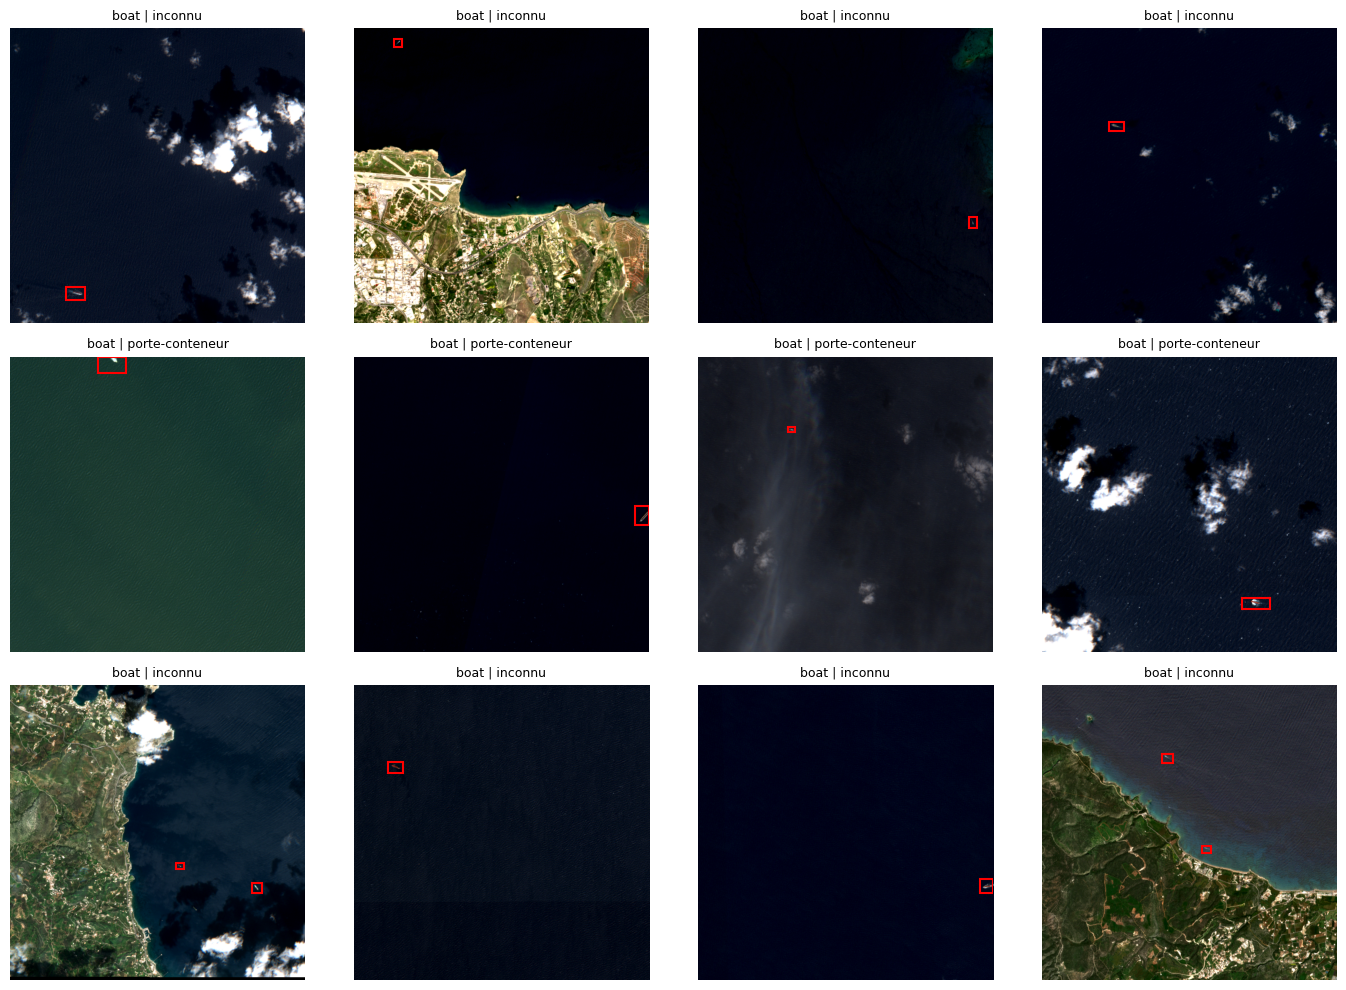

In [8]:
def show_sample_grid(max_images=12):
    if sample_manifest.empty:
        print('Aucun échantillon image disponible.')
        return

    rows = sample_manifest.head(max_images)
    n = len(rows)
    cols = 4
    fig, axes = plt.subplots((n + cols - 1) // cols, cols, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, rows.iterrows()):
        image_path = DATA_DIR / row['file_name']
        if image_path.exists():
            ax.imshow(plt.imread(image_path))
            ann = annotations[annotations['file_name'] == row['file_name']]
            for _, obj in ann.iterrows():
                ax.add_patch(Rectangle((obj['x_min'], obj['y_min']), obj['x_max'] - obj['x_min'], obj['y_max'] - obj['y_min'], fill=False, edgecolor='red', linewidth=1.5))
        ax.set_title(f"{row['sample_type']} | {row['vessel_type']}", fontsize=9)
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_sample_grid(12)

## 8. Ce que cette donnée permet de faire rapidement

Cette donnée est pertinente pour :

- comprendre une vraie structure de dataset image ;
- afficher des patches satellites annotés ;
- tester une logique de bounding boxes ;
- entraîner un premier détecteur `boat` vs fond si on télécharge plus d'images ;
- préparer un format compatible YOLO.

Elle est moins adaptée pour :

- distinguer navire civil / militaire ;
- reconnaître frégate, destroyer, porte-avions ;
- faire directement une chasse aux navires de guerre.

Pour le hackathon, elle peut donc servir de brique technique : détection de navires. La classification militaire devra venir d'une autre source, d'un enrichissement manuel, ou d'une approche métier/geospatiale.

## 9. Adaptation de la méthode de scoring

Comme ce dataset ne dit presque jamais si un bateau est militaire, le scoring ne peut pas encore être un score de menace.

On peut en revanche construire un score de priorité data pour choisir les images les plus utiles à inspecter ou annoter.

In [9]:
scored = metadata.copy()
scored['data_priority_score'] = 0
scored.loc[scored['sample_type'].eq('boat'), 'data_priority_score'] += 40
scored.loc[scored['dataset'].eq('sentinel-2-rgb'), 'data_priority_score'] += 20
scored.loc[scored['object_count'] >= 2, 'data_priority_score'] += 20
scored.loc[scored['vessel_type'].fillna('').ne('inconnu'), 'data_priority_score'] += 10
scored.loc[scored['split'].eq('test'), 'data_priority_score'] += 10

display(scored.sort_values('data_priority_score', ascending=False)[[
    'file_name', 'split', 'sample_type', 'vessel_type', 'dataset', 'object_count',
    'patch_latitude', 'patch_longitude', 'data_priority_score'
]].head(15))

,file_name,split,sample_type,vessel_type,dataset,object_count,patch_latitude,patch_longitude,data_priority_score
296,images/sentinel-2-rgb/boat/patch-29ce8d9d8089c...,test,boat,porte-conteneur,sentinel-2-rgb,7,25.368613,55.090957,100
297,images/sentinel-2-rgb/boat/patch-e9260b33e1b72...,test,boat,porte-conteneur,sentinel-2-rgb,5,25.331208,55.027369,100
287,images/sentinel-2-rgb/boat/patch-89b91b482116d...,test,boat,porte-conteneur,sentinel-2-rgb,8,25.868487,51.773051,100
268,images/sentinel-2-rgb/boat/patch-b64767a8f082f...,test,boat,porte-conteneur,sentinel-2-rgb,5,26.615882,53.975773,100
313,images/sentinel-2-rgb/boat/patch-a37e67dde147a...,test,boat,porte-conteneur,sentinel-2-rgb,3,36.653503,36.195263,100
390,images/sentinel-2-rgb/boat/patch-e0350464dddcd...,train,boat,porte-conteneur,sentinel-2-rgb,2,35.933456,14.625562,90
267,images/sentinel-2-rgb/boat/patch-a757172ce87ca...,train,boat,porte-conteneur,sentinel-2-rgb,4,29.145526,48.145038,90
270,images/sentinel-2-rgb/boat/patch-91e0d447ce657...,train,boat,porte-conteneur,sentinel-2-rgb,2,28.513115,48.987256,90
271,images/sentinel-2-rgb/boat/patch-dca6015d9e9a6...,train,boat,porte-conteneur,sentinel-2-rgb,3,26.500898,56.502425,90
272,images/sentinel-2-rgb/boat/patch-b95e32c45531a...,train,boat,porte-conteneur,sentinel-2-rgb,3,25.581028,54.429275,90


## 10. Commandes utiles

Télécharger uniquement les métadonnées :

```bash
python3 scripts/download_hf_vessel_metadata.py
```

Télécharger un petit échantillon d'images :

```bash
python3 scripts/download_hf_vessel_sample.py --boat-count 16 --negative-count 8
```

Télécharger tout le dataset, seulement si nécessaire :

```bash
hf download DefendIntelligence/vessel-detection-labeled-patches --repo-type dataset --local-dir ./data/vessel-detection-labeled-patches
```

Vu le temps disponible, le téléchargement complet n'est pas prioritaire. Un échantillon propre suffit pour comprendre et montrer la donnée.

## Conclusion opérationnelle

Ce dataset Hugging Face est une vraie donnée exploitable, mais il ne remplace pas les fichiers d'exemple du sujet.

Il faut l'utiliser ainsi :

1. `metadata.csv` et `annotations.csv` pour comprendre la vraie structure image/annotation ;
2. quelques patches téléchargés pour montrer des exemples visuels ;
3. les labels YOLO pour préparer une éventuelle détection automatique ;
4. les fichiers d'exemple du sujet pour garder la logique métier civil / militaire / scoring.

La bonne stratégie est donc hybride :

- Hugging Face pour la preuve visuelle et la détection de bateaux ;
- fichiers fournis pour le MVP métier et le score de priorité ;
- enrichissement manuel ou autre source si on veut vraiment classifier des navires militaires.